# Derivation of the Prime-Factor (Coprime) FFT and Its Use in Sparse-Support Estimation

### Abstract

The Cooley–Tukey algorithm decomposes a length-$N$ DFT into DFTs of lengths $N_1, N_2$ (with $N=N_1N_2$) at the cost of introducing $N$ twiddle-factor multiplications between the two stages. When $N_1$ and $N_2$ are *coprime*, this overhead can be eliminated entirely: the Good–Thomas **prime-factor algorithm (PFA)** re-indexes the input and output sequences using the Chinese remainder theorem (CRT), so that the length-$N$ DFT factors exactly into a two-dimensional array of length-$N_1$ and length-$N_2$ DFTs with no twiddle factors whatsoever. This notebook derives the PFA from first principles, verifies it numerically, and then examines a consequence of its CRT-indexed structure: because every frequency $k$ corresponds to a *unique* pair of residues $(k \bmod N_1,\, k \bmod N_2)$, the support of a sparse spectrum can, in principle, be identified directly from these residues. The notebook derives this idea precisely, demonstrates exact support recovery from the algorithm's natural two-dimensional output, and then examines an important limitation — spurious "ghost" frequencies that arise if only one-dimensional marginal information is retained — using a worked numerical example.

## 1. Introduction

The radix-2 decomposition considered in a companion notebook is a special case of a more general principle: a DFT of composite length $N = N_1 N_2$ can be expressed in terms of DFTs of length $N_1$ and $N_2$. In the general Cooley–Tukey factorization, this decomposition requires $N$ additional twiddle-factor multiplications to combine the two stages, regardless of whether $N_1$ and $N_2$ share common factors.

When $\gcd(N_1,N_2)=1$, however, the Chinese remainder theorem provides an alternative pair of index maps under which the decomposition requires **no twiddle factors at all**: this is the Good–Thomas prime-factor algorithm (PFA) (Good, 1958; Thomas, 1963). Beyond its computational elegance, the PFA has a structural property that is exploited in Section 7: because the CRT map is a bijection between $\{0,\dots,N-1\}$ and pairs $(k_1,k_2) \in \{0,\dots,N_1-1\}\times\{0,\dots,N_2-1\}$, each output frequency $k$ occupies a unique, predictable location in the algorithm's natural two-dimensional output array. This makes the PFA a natural tool for identifying the *support* of a sparse spectrum — the set of frequencies at which a signal has non-negligible energy — directly from the residues of the active indices, a idea related to coprime/sub-Nyquist sampling techniques used in spectrum sensing and direction-of-arrival estimation.

Section 2 reviews the DFT and the Chinese remainder theorem. Section 3 derives the coprime index maps and the resulting twiddle-factor-free factorization. Section 4 presents the corresponding computational structure graphically. Sections 5–6 provide an implementation and numerical verification. Section 7 develops and demonstrates the support-estimation application, including a worked example of the ambiguity that arises when only partial (marginal) information is retained.

## 2. Preliminaries

### 2.1 The Discrete Fourier Transform

For a sequence $x[0],\dots,x[N-1]$, the $N$-point DFT is

$$
X[k] = \sum_{n=0}^{N-1} x[n]\, W_N^{kn}, \qquad W_N \triangleq e^{-i2\pi/N}, \qquad k=0,\dots,N-1. \tag{1}
$$

### 2.2 The Chinese Remainder Theorem

Let $N_1, N_2$ be coprime positive integers and $N = N_1N_2$. Because $\gcd(N_1,N_2)=1$, Bézout's identity guarantees the existence of integers $u,v$ such that

$$
u\,N_1 + v\,N_2 = 1. \tag{2}
$$

Define the **CRT idempotents**

$$
e_1 \triangleq (v\,N_2) \bmod N, \qquad e_2 \triangleq (u\,N_1) \bmod N. \tag{3}
$$

From Equation (2), $v N_2 \equiv 1 \pmod{N_1}$ and $v N_2 \equiv 0 \pmod{N_2}$ (being a multiple of $N_2$), so $e_1 \equiv 1 \pmod{N_1}$ and $e_1 \equiv 0 \pmod{N_2}$; symmetrically, $e_2 \equiv 0 \pmod{N_1}$ and $e_2 \equiv 1 \pmod{N_2}$. Consequently, for any residues $k_1 \in \{0,\dots,N_1-1\}$ and $k_2 \in \{0,\dots,N_2-1\}$, the integer

$$
k(k_1,k_2) \;\triangleq\; (k_1 e_1 + k_2 e_2) \bmod N \tag{4}
$$

satisfies $k \equiv k_1 \pmod{N_1}$ and $k \equiv k_2 \pmod{N_2}$, and is the *unique* such integer in $\{0,\dots,N-1\}$ (uniqueness follows because two solutions would differ by a multiple of both $N_1$ and $N_2$, hence, by coprimality, by a multiple of $N$). Equation (4) thus defines a bijection between $\{0,\dots,N-1\}$ and $\{0,\dots,N_1-1\}\times\{0,\dots,N_2-1\}$; this bijection is used twice below, once for the output index $k$ and once, in a different form, for the input index $n$.

In [1]:
import numpy as np

def egcd(a, b):
    """Extended Euclidean algorithm: returns (g, x, y) with a*x + b*y = g = gcd(a,b)."""
    if b == 0:
        return a, 1, 0
    g, x1, y1 = egcd(b, a % b)
    return g, y1, x1 - (a // b) * y1

def modinv(a, m):
    """Modular inverse of a modulo m, via Eq. (2)."""
    g, x, _ = egcd(a % m, m)
    if g != 1:
        raise ValueError(f"{a} has no inverse modulo {m}")
    return x % m

def crt_reconstruct(k1, k2, N1, N2):
    """Reconstruct k from residues (k1 mod N1, k2 mod N2), per Eqs. (2)-(4)."""
    N = N1 * N2
    g, u, v = egcd(N1, N2)
    assert g == 1, "N1 and N2 must be coprime"
    e1 = (v * N2) % N
    e2 = (u * N1) % N
    return (k1 * e1 + k2 * e2) % N

# sanity check of the bijection for a small coprime pair
N1, N2 = 5, 7
for k in range(N1 * N2):
    k1, k2 = k % N1, k % N2
    assert crt_reconstruct(k1, k2, N1, N2) == k
print("CRT reconstruction verified for all k in range(N1*N2) =", N1*N2)


CRT reconstruction verified for all k in range(N1*N2) = 35


## 3. The Coprime Index Maps and the Twiddle-Factor-Free Decomposition

### 3.1 Index Maps

Two index maps are required: one for the input sequence, and one (already given, Equation (4)) for the output sequence. Analogously to Equation (4), define the **input map**

$$
n(n_1,n_2) \;\triangleq\; (n_1 N_2 + n_2 N_1) \bmod N, \qquad n_1=0,\dots,N_1-1,\;\; n_2 = 0,\dots,N_2-1. \tag{5}
$$

Equation (5) is also a bijection between $\{0,\dots,N-1\}$ and $\{0,\dots,N_1-1\}\times\{0,\dots,N_2-1\}$ (it is sometimes called the *Ruritanian* map, in contrast with the *CRT map* of Equation (4); the derivation below shows that pairing a Ruritanian input map with a CRT output map — or vice versa — is precisely what eliminates the twiddle factors).

### 3.2 Derivation of the Factorization

The goal is to show that, under the maps of Equations (4)–(5), the exponent $kn$ in Equation (1) separates into independent contributions from $(k_1,n_1)$ and $(k_2,n_2)$.

**Lemma.** For $k=k(k_1,k_2)$ as in Equation (4) and any integers $n_1,n_2$,

$$
k\,n_1 N_2 \equiv k_1\, n_1 N_2 \pmod{N}, \qquad k\,n_2 N_1 \equiv k_2\, n_2 N_1 \pmod{N}. \tag{6}
$$

*Proof.* Write $k = k_1 + N_1 m$ for some integer $m$ (possible since $k \equiv k_1 \pmod{N_1}$). Then $k\,n_1 N_2 = k_1 n_1 N_2 + m n_1 N_1 N_2 = k_1 n_1 N_2 + m n_1 N$, and since $mn_1N \equiv 0 \pmod N$, the first relation of Equation (6) follows. The second follows identically, writing $k = k_2 + N_2 m'$. $\blacksquare$

Adding the two relations in Equation (6),

$$
kn(n_1,n_2) = k\big(n_1N_2 + n_2N_1\big) \equiv k_1n_1N_2 + k_2n_2N_1 \pmod N, \tag{7}
$$

where the left-hand equality used $n \equiv n_1N_2+n_2N_1 \pmod N$ from Equation (5) (note $kn$ is only needed modulo $N$, since $W_N^{kn}$ depends only on $kn \bmod N$). Substituting Equation (7) into the twiddle factor of Equation (1),

$$
W_N^{kn} = e^{-i\frac{2\pi}{N}kn} = e^{-i\frac{2\pi}{N}(k_1n_1N_2+k_2n_2N_1)} = e^{-i\frac{2\pi}{N_1}k_1n_1}\; e^{-i\frac{2\pi}{N_2}k_2n_2} = W_{N_1}^{k_1n_1}\, W_{N_2}^{k_2n_2}, \tag{8}
$$

using $N=N_1N_2$ to cancel the common factor in each exponent. Equation (8) contains **no cross terms** between $(k_1,n_2)$ or $(k_2,n_1)$ — in contrast with the general Cooley–Tukey factorization, whose analogous exponent splits into a product of *three* factors, the third being a twiddle factor depending jointly on $k_1$ and $n_2$.

### 3.3 The Resulting Two-Dimensional DFT

Substituting Equation (8) into Equation (1), and writing $x_2[n_1,n_2] \triangleq x[n(n_1,n_2)]$ for the input reshaped according to Equation (5),

$$
X\big[k(k_1,k_2)\big] = \sum_{n_1=0}^{N_1-1} W_{N_1}^{k_1n_1} \underbrace{\left[\sum_{n_2=0}^{N_2-1} x_2[n_1,n_2]\, W_{N_2}^{k_2n_2}\right]}_{\textstyle \triangleq\, Y[n_1,k_2]}. \tag{9}
$$

Equation (9) states that $X$, reshaped according to the CRT output map, is obtained from $x$, reshaped according to the Ruritanian input map, by: (i) applying $N_1$ independent length-$N_2$ DFTs, one along each row $n_1$, producing $Y[n_1,k_2]$; and (ii) applying $N_2$ independent length-$N_1$ DFTs, one along each column $k_2$, producing $Z[k_1,k_2] \triangleq X[k(k_1,k_2)]$. No multiplication by any factor other than the roots of unity internal to these smaller DFTs is required.

## 4. Computational Structure

Figure 1 summarizes the pipeline implied by Equations (5)–(9). Figure 2 illustrates the reshaping and the two transform directions explicitly for the small coprime pair $(N_1,N_2)=(3,4)$.

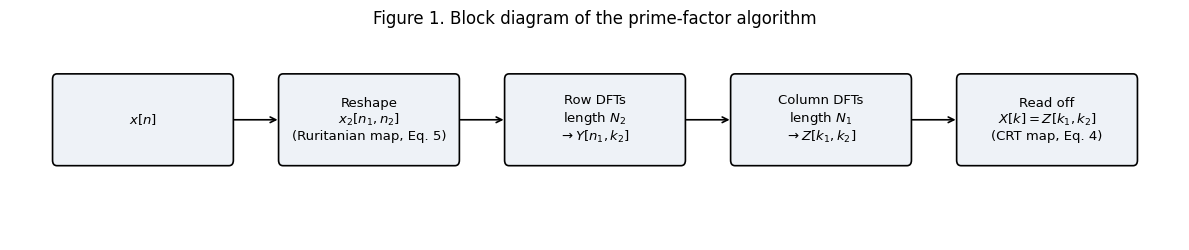

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_pipeline(ax, boxes, y=0.0, box_w=1.7, box_h=0.8, gap=0.55, fontsize=9.5):
    xs = []
    x = 0.0
    for label in boxes:
        rect = mpatches.FancyBboxPatch((x, y), box_w, box_h,
                                        boxstyle="round,pad=0.02,rounding_size=0.05",
                                        linewidth=1.2, edgecolor='black', facecolor='#eef2f7')
        ax.add_patch(rect)
        ax.text(x + box_w/2, y + box_h/2, label, ha='center', va='center', fontsize=fontsize)
        xs.append(x)
        x += box_w + gap
    for x0 in xs[:-1]:
        ax.annotate("", xy=(x0 + box_w + gap, y + box_h/2), xytext=(x0 + box_w, y + box_h/2),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color='black'))
    return xs, box_w, box_h

fig, ax = plt.subplots(figsize=(12, 2.6))
boxes = [
    "$x[n]$",
    "Reshape\n$x_2[n_1,n_2]$\n(Ruritanian map, Eq. 5)",
    "Row DFTs\nlength $N_2$\n$\\to Y[n_1,k_2]$",
    "Column DFTs\nlength $N_1$\n$\\to Z[k_1,k_2]$",
    "Read off\n$X[k]=Z[k_1,k_2]$\n(CRT map, Eq. 4)",
]
xs, bw, bh = draw_pipeline(ax, boxes, y=0.4, box_w=2.0)
ax.set_xlim(-0.5, xs[-1] + bw + 0.5)
ax.set_ylim(-0.3, 1.6)
ax.axis('off')
ax.set_title("Figure 1. Block diagram of the prime-factor algorithm", fontsize=12)
plt.tight_layout()
plt.show()


**Figure 1.** Computational structure of the Good–Thomas prime-factor algorithm. Unlike the general Cooley–Tukey pipeline, no twiddle-factor multiplication stage appears between the row and column transforms.

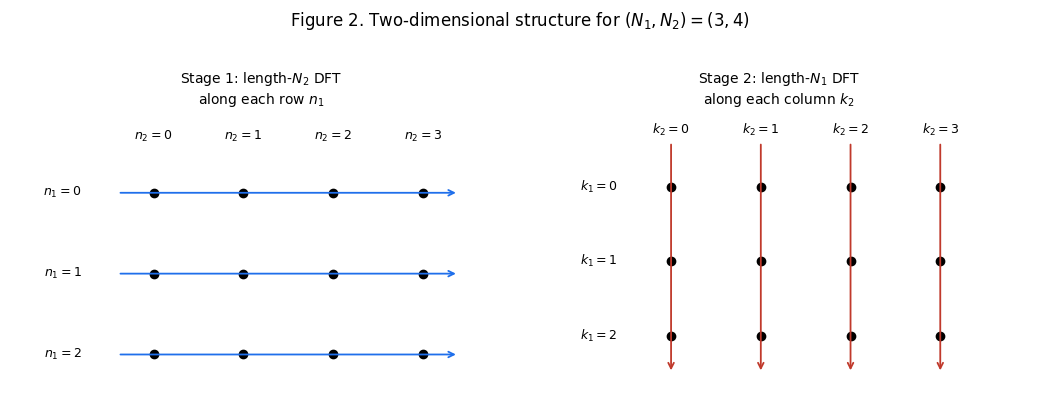

In [3]:
N1_ex, N2_ex = 3, 4
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))

# left: array indexed by (n1,n2), row DFTs along n2
for n1 in range(N1_ex):
    for n2 in range(N2_ex):
        ax[0].plot(n2, N1_ex-1-n1, 'o', color='black', markersize=6, zorder=3)
    ax[0].annotate("", xy=(N2_ex-0.6, N1_ex-1-n1), xytext=(-0.4, N1_ex-1-n1),
                   arrowprops=dict(arrowstyle="->", lw=1.3, color='#1f6feb'))
for n1 in range(N1_ex):
    ax[0].text(-0.8, N1_ex-1-n1, f"$n_1={n1}$", ha='right', va='center', fontsize=9)
for n2 in range(N2_ex):
    ax[0].text(n2, N1_ex-0.4, f"$n_2={n2}$", ha='center', va='bottom', fontsize=9)
ax[0].set_xlim(-1.6, N2_ex)
ax[0].set_ylim(-0.6, N1_ex)
ax[0].axis('off')
ax[0].set_title("Stage 1: length-$N_2$ DFT\nalong each row $n_1$", fontsize=10)

# right: array indexed by (k1,k2), column DFTs along k1
for k2 in range(N2_ex):
    for k1 in range(N1_ex):
        ax[1].plot(k2, N1_ex-1-k1, 'o', color='black', markersize=6, zorder=3)
    ax[1].annotate("", xy=(k2, -0.5), xytext=(k2, N1_ex-0.4),
                   arrowprops=dict(arrowstyle="->", lw=1.3, color='#c0392b'))
for k1 in range(N1_ex):
    ax[1].text(-0.6, N1_ex-1-k1, f"$k_1={k1}$", ha='right', va='center', fontsize=9)
for k2 in range(N2_ex):
    ax[1].text(k2, N1_ex-0.35, f"$k_2={k2}$", ha='center', va='bottom', fontsize=9)
ax[1].set_xlim(-1.6, N2_ex)
ax[1].set_ylim(-0.9, N1_ex)
ax[1].axis('off')
ax[1].set_title("Stage 2: length-$N_1$ DFT\nalong each column $k_2$", fontsize=10)

fig.suptitle(f"Figure 2. Two-dimensional structure for $(N_1,N_2)=({N1_ex},{N2_ex})$", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Figure 2.** Illustration of Equation (9) for $(N_1,N_2)=(3,4)$, $N=12$: after reshaping $x$ according to the Ruritanian map (Eq. 5), length-$N_2$ DFTs are applied along each row $n_1$ (left), followed by length-$N_1$ DFTs along each column $k_2$ of the resulting array (right). The final array, indexed by $(k_1,k_2)$, is read out to $X[k]$ via the CRT map (Eq. 4).

## 5. Implementation

In [4]:
def dft_direct(x):
    """Direct O(N^2) DFT, used here for the (short) sub-transforms of Eq. (9)."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

def pfa_fft(x, N1, N2, return_2d=False):
    """Good-Thomas prime-factor FFT for N = N1*N2, gcd(N1,N2)=1, per Eqs. (5)-(9).
    The sub-transforms are computed with dft_direct; in practice these could be
    replaced by the radix-2 FFT, Rader's algorithm, or Bluestein's algorithm
    (derived in companion notebooks) whenever N1 or N2 admit them, without
    changing the index-mapping structure derived above."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    assert N1 * N2 == N
    g, u, v = egcd(N1, N2)
    assert g == 1, "N1 and N2 must be coprime"
    e1 = (v * N2) % N
    e2 = (u * N1) % N

    # reshape x into x2[n1,n2] via the Ruritanian input map, Eq. (5)
    x2 = np.zeros((N1, N2), dtype=complex)
    for n1 in range(N1):
        for n2 in range(N2):
            x2[n1, n2] = x[(n1 * N2 + n2 * N1) % N]

    # Stage 1: length-N2 DFT along each row n1  ->  Y[n1, k2]
    Y = np.array([dft_direct(x2[n1, :]) for n1 in range(N1)])

    # Stage 2: length-N1 DFT along each column k2  ->  Z[k1, k2]
    Z = np.array([dft_direct(Y[:, k2]) for k2 in range(N2)]).T

    if return_2d:
        return Z, e1, e2

    # read off X[k] via the CRT output map, Eq. (4)
    X = np.zeros(N, dtype=complex)
    for k1 in range(N1):
        for k2 in range(N2):
            X[(k1 * e1 + k2 * e2) % N] = Z[k1, k2]
    return X


## 6. Numerical Verification

The prime-factor algorithm is verified against direct evaluation of Equation (1) for several coprime pairs $(N_1,N_2)$.

In [5]:
np.random.seed(0)
print(f"{'N1':>4} {'N2':>4} {'N':>5} | {'max |direct - PFA|':>20}")
for (N1, N2) in [(3,4), (4,5), (3,5), (5,7), (8,9)]:
    N = N1 * N2
    x = np.random.randn(N) + 1j * np.random.randn(N)
    X_direct = dft_direct(x)
    X_pfa = pfa_fft(x, N1, N2)
    print(f"{N1:4d} {N2:4d} {N:5d} | {np.max(np.abs(X_direct - X_pfa)):20.3e}")


  N1   N2     N |   max |direct - PFA|
   3    4    12 |            2.317e-14
   4    5    20 |            6.873e-14
   3    5    15 |            3.267e-14
   5    7    35 |            1.502e-13
   8    9    72 |            7.333e-13


Agreement to within floating-point precision confirms the factorization derived in Equations (5)–(9).

## 7. Application: Estimating the Support of a Sparse Spectrum

### 7.1 Exact Recovery from the Joint Array

Suppose $x$ has a **sparse** spectrum: $X[k]=0$ except for $k$ in a small support set $S \subset \{0,\dots,N-1\}$, $|S|=K \ll N$. By the bijectivity of the CRT map established in Section 2.2, each $k \in S$ corresponds to a unique pair $(k_1,k_2) = (k \bmod N_1,\, k \bmod N_2)$, which is precisely the array position $Z[k_1,k_2]$ computed by Equation (9). Consequently, the support $S$ can be read off **exactly** from the locations of the non-negligible entries of the two-dimensional array $Z$, by inverting the CRT map (Eq. 4) at each such location — no additional computation beyond evaluating Equation (9) is required. This is verified numerically below for a signal with $K=3$ active frequencies.

In [6]:
def support_from_joint_array(Z, e1, e2, N, thresh_ratio=1e-6):
    """Recover support exactly from the joint array Z, per Section 7.1."""
    mag2 = np.abs(Z) ** 2
    thresh = mag2.max() * thresh_ratio
    support = set()
    for k1, k2 in np.argwhere(mag2 > thresh):
        support.add(int((k1 * e1 + k2 * e2) % N))
    return support

np.random.seed(1)
N1, N2 = 5, 7
N = N1 * N2
true_support = sorted(np.random.choice(N, size=3, replace=False))

X_true = np.zeros(N, dtype=complex)
for k in true_support:
    X_true[k] = np.exp(1j * np.random.uniform(0, 2*np.pi))   # unit-magnitude, random phase
x = np.fft.ifft(X_true) * N   # x with fft(x) = X_true, under the Eq. (1) convention

Z, e1, e2 = pfa_fft(x, N1, N2, return_2d=True)
recovered = support_from_joint_array(Z, e1, e2, N)

print("true support      :", true_support)
print("recovered support :", sorted(recovered))
print("exact match        :", set(true_support) == recovered)


true support      : [np.int64(3), np.int64(14), np.int64(19)]
recovered support : [3, 14, 19]
exact match        : True


### 7.2 The Marginal-Information Ambiguity

The exact recovery of Section 7.1 relies on retaining the full two-dimensional array $Z[k_1,k_2]$. Suppose instead that only the two one-dimensional marginal energies

$$
R[k_1] \triangleq \sum_{k_2=0}^{N_2-1} |Z[k_1,k_2]|^2, \qquad C[k_2] \triangleq \sum_{k_1=0}^{N_1-1} |Z[k_1,k_2]|^2 \tag{10}
$$

are retained — for instance because only aggregate energy at each residue was measured, as in certain coprime-sampling or coprime-array sensing schemes, rather than the full joint array. Let $\hat{S}_1 = \{k_1 : R[k_1] > \text{threshold}\}$ and $\hat{S}_2 = \{k_2 : C[k_2] > \text{threshold}\}$ denote the active residues identified from each marginal. Because the joint array is not observed, the only recoverable candidate set is the **Cartesian product**

$$
\hat{S} \;\triangleq\; \big\{\, k(k_1,k_2) \;:\; k_1 \in \hat{S}_1,\ k_2 \in \hat{S}_2 \,\big\}, \tag{11}
$$

via Equation (4). When $K=|S|=1$, $\hat{S}_1$ and $\hat{S}_2$ each contain a single element and $\hat S = S$ exactly. When $K>1$, however, $|\hat S_1|$ and $|\hat S_2|$ may each exceed $1$, so that $|\hat S| = |\hat S_1|\cdot|\hat S_2|$ can exceed $K$: the additional elements of $\hat S \setminus S$ are **ghost frequencies** — combinations of residues that are each individually active in some true frequency, but whose particular pairing does not correspond to any true frequency. This is demonstrated numerically below for two frequencies chosen to have distinct residues in both moduli.

In [7]:
def support_from_marginals(Z, e1, e2, N1, N2, N, thresh_ratio=1e-6):
    """Recover a candidate support set from marginal energies only, per Eqs. (10)-(11)."""
    mag2 = np.abs(Z) ** 2
    R = mag2.sum(axis=1)
    C = mag2.sum(axis=0)
    thresh = mag2.max() * thresh_ratio
    active_k1 = np.where(R > thresh)[0]
    active_k2 = np.where(C > thresh)[0]
    candidates = {int((k1 * e1 + k2 * e2) % N) for k1 in active_k1 for k2 in active_k2}
    return candidates

# choose two true frequencies with DISTINCT residues mod N1 and mod N2
N1, N2 = 5, 7
N = N1 * N2
true_support = [3, 11]     # 3 -> (3 mod 5, 3 mod 7) = (3,3);  11 -> (1 mod 5, 4 mod 7) = (1,4)

X_true = np.zeros(N, dtype=complex)
for k in true_support:
    X_true[k] = 1.0 + 0j
x = np.fft.ifft(X_true) * N

Z, e1, e2 = pfa_fft(x, N1, N2, return_2d=True)
exact = support_from_joint_array(Z, e1, e2, N)
candidates = support_from_marginals(Z, e1, e2, N1, N2, N)

print("true support                       :", true_support)
print("exact recovery from joint array Z  :", sorted(exact))
print("candidates from marginals R, C     :", sorted(candidates))
print("ghost frequencies (candidates - S) :", sorted(candidates - set(true_support)))


true support                       : [3, 11]
exact recovery from joint array Z  : [3, 11]
candidates from marginals R, C     : [3, 11, 18, 31]
ghost frequencies (candidates - S) : [18, 31]


As anticipated, the joint array yields the true support exactly, whereas the marginal-only candidate set contains additional ghost frequencies — here, the two "cross" combinations of the active residues that do not correspond to true frequencies. Resolving this ambiguity in general requires either retaining joint (rather than marginal) information, as in Section 7.1, or additional structure, such as a bound $K < \min(N_1,N_2)$ together with amplitude- or phase-consistency checks across coprime moduli, or the use of multiple coprime pairs (analogous to ambiguity resolution via staggered pulse-repetition frequencies in radar). This trade-off — between the reduced observation required by the marginals and the exact but fully joint information required for unambiguous recovery — is the central difficulty in coprime-sensing approaches to sparse spectrum estimation.

## 8. Complexity Remark

The implementation of Section 5 evaluates each length-$N_1$ or length-$N_2$ sub-transform directly, at cost $O(N_1^2)$ and $O(N_2^2)$ respectively, giving an overall cost of $O(N_1N(N_1+N_2)/N) \cdot$ — more precisely, $O(N(N_1+N_2))$ for all sub-transforms combined, which is asymptotically better than the direct $O(N^2)$ cost of Equation (1) whenever $N_1,N_2 \ll N$. As with Rader's and Bluestein's algorithms (companion notebooks), nothing in the derivation of Equations (5)–(9) requires the sub-transforms to be evaluated directly: replacing `dft_direct` with the radix-2 FFT whenever $N_1$ or $N_2$ is a power of two, or with Rader's or Bluestein's algorithm whenever a factor is prime, yields an overall $O(N\log_2 N)$ algorithm for any $N$ that admits a coprime factorization into such pieces — which, by repeated application, includes every $N>1$.

## 9. Conclusion

This notebook derived the Good–Thomas prime-factor algorithm from the Chinese remainder theorem: pairing a Ruritanian input map (Eq. 5) with a CRT output map (Eq. 4) was shown, via the lemma of Equation (6), to factor the DFT exactly into a two-dimensional array of smaller DFTs with no twiddle factors (Eqs. 8–9). This was verified numerically in Section 6. Section 7 then used the resulting CRT-indexed structure to estimate the support of a sparse spectrum: Section 7.1 showed that the joint two-dimensional output array yields the support exactly, while Section 7.2 showed, with an explicit numerical example, that discarding joint information in favor of one-dimensional marginals reintroduces ambiguity in the form of ghost frequencies, Equations (10)–(11). This illustrates both the elegance of coprime index mapping for exact fast transforms and the care required when such structure is exploited for reduced-observation spectrum estimation.